In [1]:
import pandas as pd
import numpy as np
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [2]:
df = pd.read_csv("../data/processed/datas_cleaned.csv")
df["item_id"] = df["region"] + "_" + df["size_rank"].astype(str)
df["timestamp"] = pd.to_datetime((df["year"] - 543).astype(str))

ts_df = TimeSeriesDataFrame.from_data_frame(
    df[["item_id", "timestamp", "value", "tourists_mn"]],
    id_column="item_id",
    timestamp_column="timestamp",
)

In [3]:
train_data = ts_df.loc[ts_df.index.get_level_values("timestamp") <= "2011-01-01"]

In [4]:
save_path_backtest = "../AutogluonModels/TimeSeriesPredictor_Backtest"
predictor_backtest = TimeSeriesPredictor(
    prediction_length=2,
    target="value",
    eval_metric="MASE",
    known_covariates_names=["tourists_mn"],
    path=save_path_backtest,
).fit(train_data, presets="best_quality", time_limit=600)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to 'd:\Mini Project\Term Project\AutogluonModels\TimeSeriesPredictor_Backtest'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.10
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          20
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       7.02 GB / 15.73 GB (44.6%)
Disk Space Avail:   635.33 GB / 953.85 GB (66.6%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': ['tourists_mn'],
 'num_val_windows': 'auto',
 'prediction_length': 2,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 

In [5]:
predictor_backtest.evaluate(train_data)

Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


{'MASE': -18.881442702577658}

In [6]:
predictor_backtest.leaderboard()

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-18.881443,0.129378,0.438000,11
1,Chronos2SmallFineTuned,-18.881443,0.129378,90.086925,6
2,DeepAR,-19.280614,0.058540,37.846836,10
3,RecursiveTabular,-19.743604,0.041072,0.537641,2
4,Chronos2,-19.827546,0.481762,6.941251,5
5,DynamicOptimizedTheta,-19.916409,2.487601,0.018912,4
6,TemporalFusionTransformer,-19.974098,0.037000,147.476367,9
7,SeasonalNaive,-20.090303,10.047257,0.015066,1
8,AutoETS,-20.090303,0.034031,0.022002,7
9,ChronosWithRegressor[bolt_small],-20.192384,1.766232,0.613684,8


In [7]:
future_covariates = ts_df.loc[
    ts_df.index.get_level_values("timestamp") > "2011-01-01", ["tourists_mn"]
]

In [8]:
predictions = predictor_backtest.predict(train_data, known_covariates=future_covariates)
predictions

Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


mean           0.1           0.2  \
item_id        timestamp                                              
Bangkok_1      2013-01-01  3.553516e+09  7.727775e+08  1.575312e+09   
               2015-01-01  3.708856e+09  4.297270e+08  1.280209e+09   
Bangkok_2      2013-01-01  8.553748e+09  3.230757e+09  5.012163e+09   
               2015-01-01  9.058038e+09  2.645933e+09  4.538407e+09   
Bangkok_3      2013-01-01  3.148908e+10  2.001334e+10  2.447470e+10   
               2015-01-01  3.189336e+10  1.861501e+10  2.383564e+10   
Central_1      2013-01-01  1.802875e+10  6.049339e+09  1.013155e+10   
               2015-01-01  1.853760e+10  4.605988e+09  8.864170e+09   
Central_2      2013-01-01  1.205966e+10  5.817305e+09  8.053852e+09   
               2015-01-01  1.234816e+10  5.550249e+09  7.911962e+09   
Central_3      2013-01-01  2.236181e+10  1.195776e+10  1.574710e+10   
               2015-01-01  2.310625e+10  1.140555e+10  1.546951e+10   
Northern_1     2013-01-01  9.923860e+09  2.833991e+09  5.230939e+09   
               2015-01-01  1.030800e+10  1.918827e+09  4.337488e+09   
Northern_2     2013-01-01  6.629028e+09  2.517268e+09  3.903517e+09   
               2015-01-01  6.829893e+09  1.989956e+09  3.421842e+09   
Northern_3     2013-01-01  6.543770e+09  2.112963e+09  3.382583e+09   
               2015-01-01  6.554078e+09  1.955062e+09  3.311057e+09   
Northeastern_1 2013-01-01  5.400613e+09  1.988419e+09  3.154636e+09   
               2015-01-01  5.533691e+09  1.604814e+09  2.831934e+09   
Northeastern_2 2013-01-01  4.177562e+09  1.849887e+09  2.679165e+09   
               2015-01-01  4.354152e+09  1.554582e+09  2.432326e+09   
Northeastern_3 2013-01-01  4.880899e+09  2.127342e+09  3.176387e+09   
               2015-01-01  5.052394e+09  1.819448e+09  2.923052e+09   
Southern_1     2013-01-01  4.119826e+10  1.137231e+10  2.152782e+10   
               2015-01-01  4.285708e+10  7.580749e+09  1.784888e+10   
Southern_2     2013-01-01  1.903940e+10  8.945041e+09  1.230787e+10   
               2015-01-01  1.994123e+10  8.092745e+09  1.173174e+10   
Southern_3     2013-01-01  3.037852e+10  1.416526e+10  2.035044e+10   
               2015-01-01  3.058561e+10  1.239609e+10  1.874826e+10   

                                    0.3           0.4           0.5  \
item_id        timestamp                                              
Bangkok_1      2013-01-01  2.283488e+09  2.900247e+09  3.553516e+09   
               2015-01-01  2.136628e+09  2.948975e+09  3.708856e+09   
Bangkok_2      2013-01-01  6.355652e+09  7.479657e+09  8.553748e+09   
               2015-01-01  6.266509e+09  7.805154e+09  9.058038e+09   
Bangkok_3      2013-01-01  2.713318e+10  2.931159e+10  3.148908e+10   
               2015-01-01  2.696244e+10  2.949491e+10  3.189336e+10   
Central_1      2013-01-01  1.310815e+10  1.562167e+10  1.802875e+10   
               2015-01-01  1.258545e+10  1.586917e+10  1.853760e+10   
Central_2      2013-01-01  9.599233e+09  1.086788e+10  1.205966e+10   
               2015-01-01  9.564045e+09  1.102641e+10  1.234816e+10   
Central_3      2013-01-01  1.834249e+10  2.043813e+10  2.236181e+10   
               2015-01-01  1.836136e+10  2.088915e+10  2.310625e+10   
Northern_1     2013-01-01  6.961424e+09  8.432804e+09  9.923860e+09   
               2015-01-01  6.559739e+09  8.606099e+09  1.030800e+10   
Northern_2     2013-01-01  4.927088e+09  5.792992e+09  6.629028e+09   
               2015-01-01  4.723356e+09  5.891567e+09  6.829893e+09   
Northern_3     2013-01-01  4.406322e+09  5.452481e+09  6.543770e+09   
               2015-01-01  4.352420e+09  5.431068e+09  6.554078e+09   
Northeastern_1 2013-01-01  4.001464e+09  4.715190e+09  5.400613e+09   
               2015-01-01  3.870240e+09  4.779771e+09  5.533691e+09   
Northeastern_2 2013-01-01  3.288179e+09  3.768815e+09  4.177562e+09   
               2015-01-01  3.188985e+09  3.850204e+09  4.354152e+09   
Northeastern_3 2013-01-01  3.868127e+09  4.403752e+09  4.8

In [9]:
actual_values = ts_df.loc[
    ts_df.index.get_level_values("timestamp") > "2011-01-01", ["value"]
]
actual_values = actual_values.rename(columns={"value": "actual_value"})
comparison = predictions.join(actual_values).reset_index()
comparison["year_th"] = comparison["timestamp"].dt.year + 543
comparison = comparison[["item_id", "year_th", "actual_value", "mean", "0.1", "0.9"]]
comparison["error_%"] = (
    abs(comparison["mean"] - comparison["actual_value"]) / comparison["actual_value"]
) * 100
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
display(comparison)

,item_id,year_th,actual_value,mean,0.1,0.9,error_%
0,Bangkok_1,2556,"2,158,830,400","3,553,516,032","772,777,536","10,509,169,664",65
1,Bangkok_1,2558,"2,785,766,400","3,708,855,808","429,727,040","11,036,380,160",33
2,Bangkok_2,2556,"6,620,012,700","8,553,748,480","3,230,756,864","20,164,618,240",29
3,Bangkok_2,2558,"16,872,941,700","9,058,037,760","2,645,932,544","21,512,151,040",46
4,Bangkok_3,2556,"39,595,939,200","31,489,081,344","20,013,342,720","52,871,684,096",20
5,Bangkok_3,2558,"42,655,137,500","31,893,364,736","18,615,009,280","54,875,840,512",25
6,Central_1,2556,"5,983,787,200","18,028,754,944","6,049,339,392","43,208,089,600",201
7,Central_1,2558,"6,678,685,800","18,537,601,024","4,605,987,840","45,301,567,488",178
8,Central_2,2556,"7,205,202,200","12,059,663,360","5,817,305,088","22,898,995,200",67
9,Central_2,2558,"7,613,535,400","12,348,163,072","5,550,248,960","24,329,216,000",62


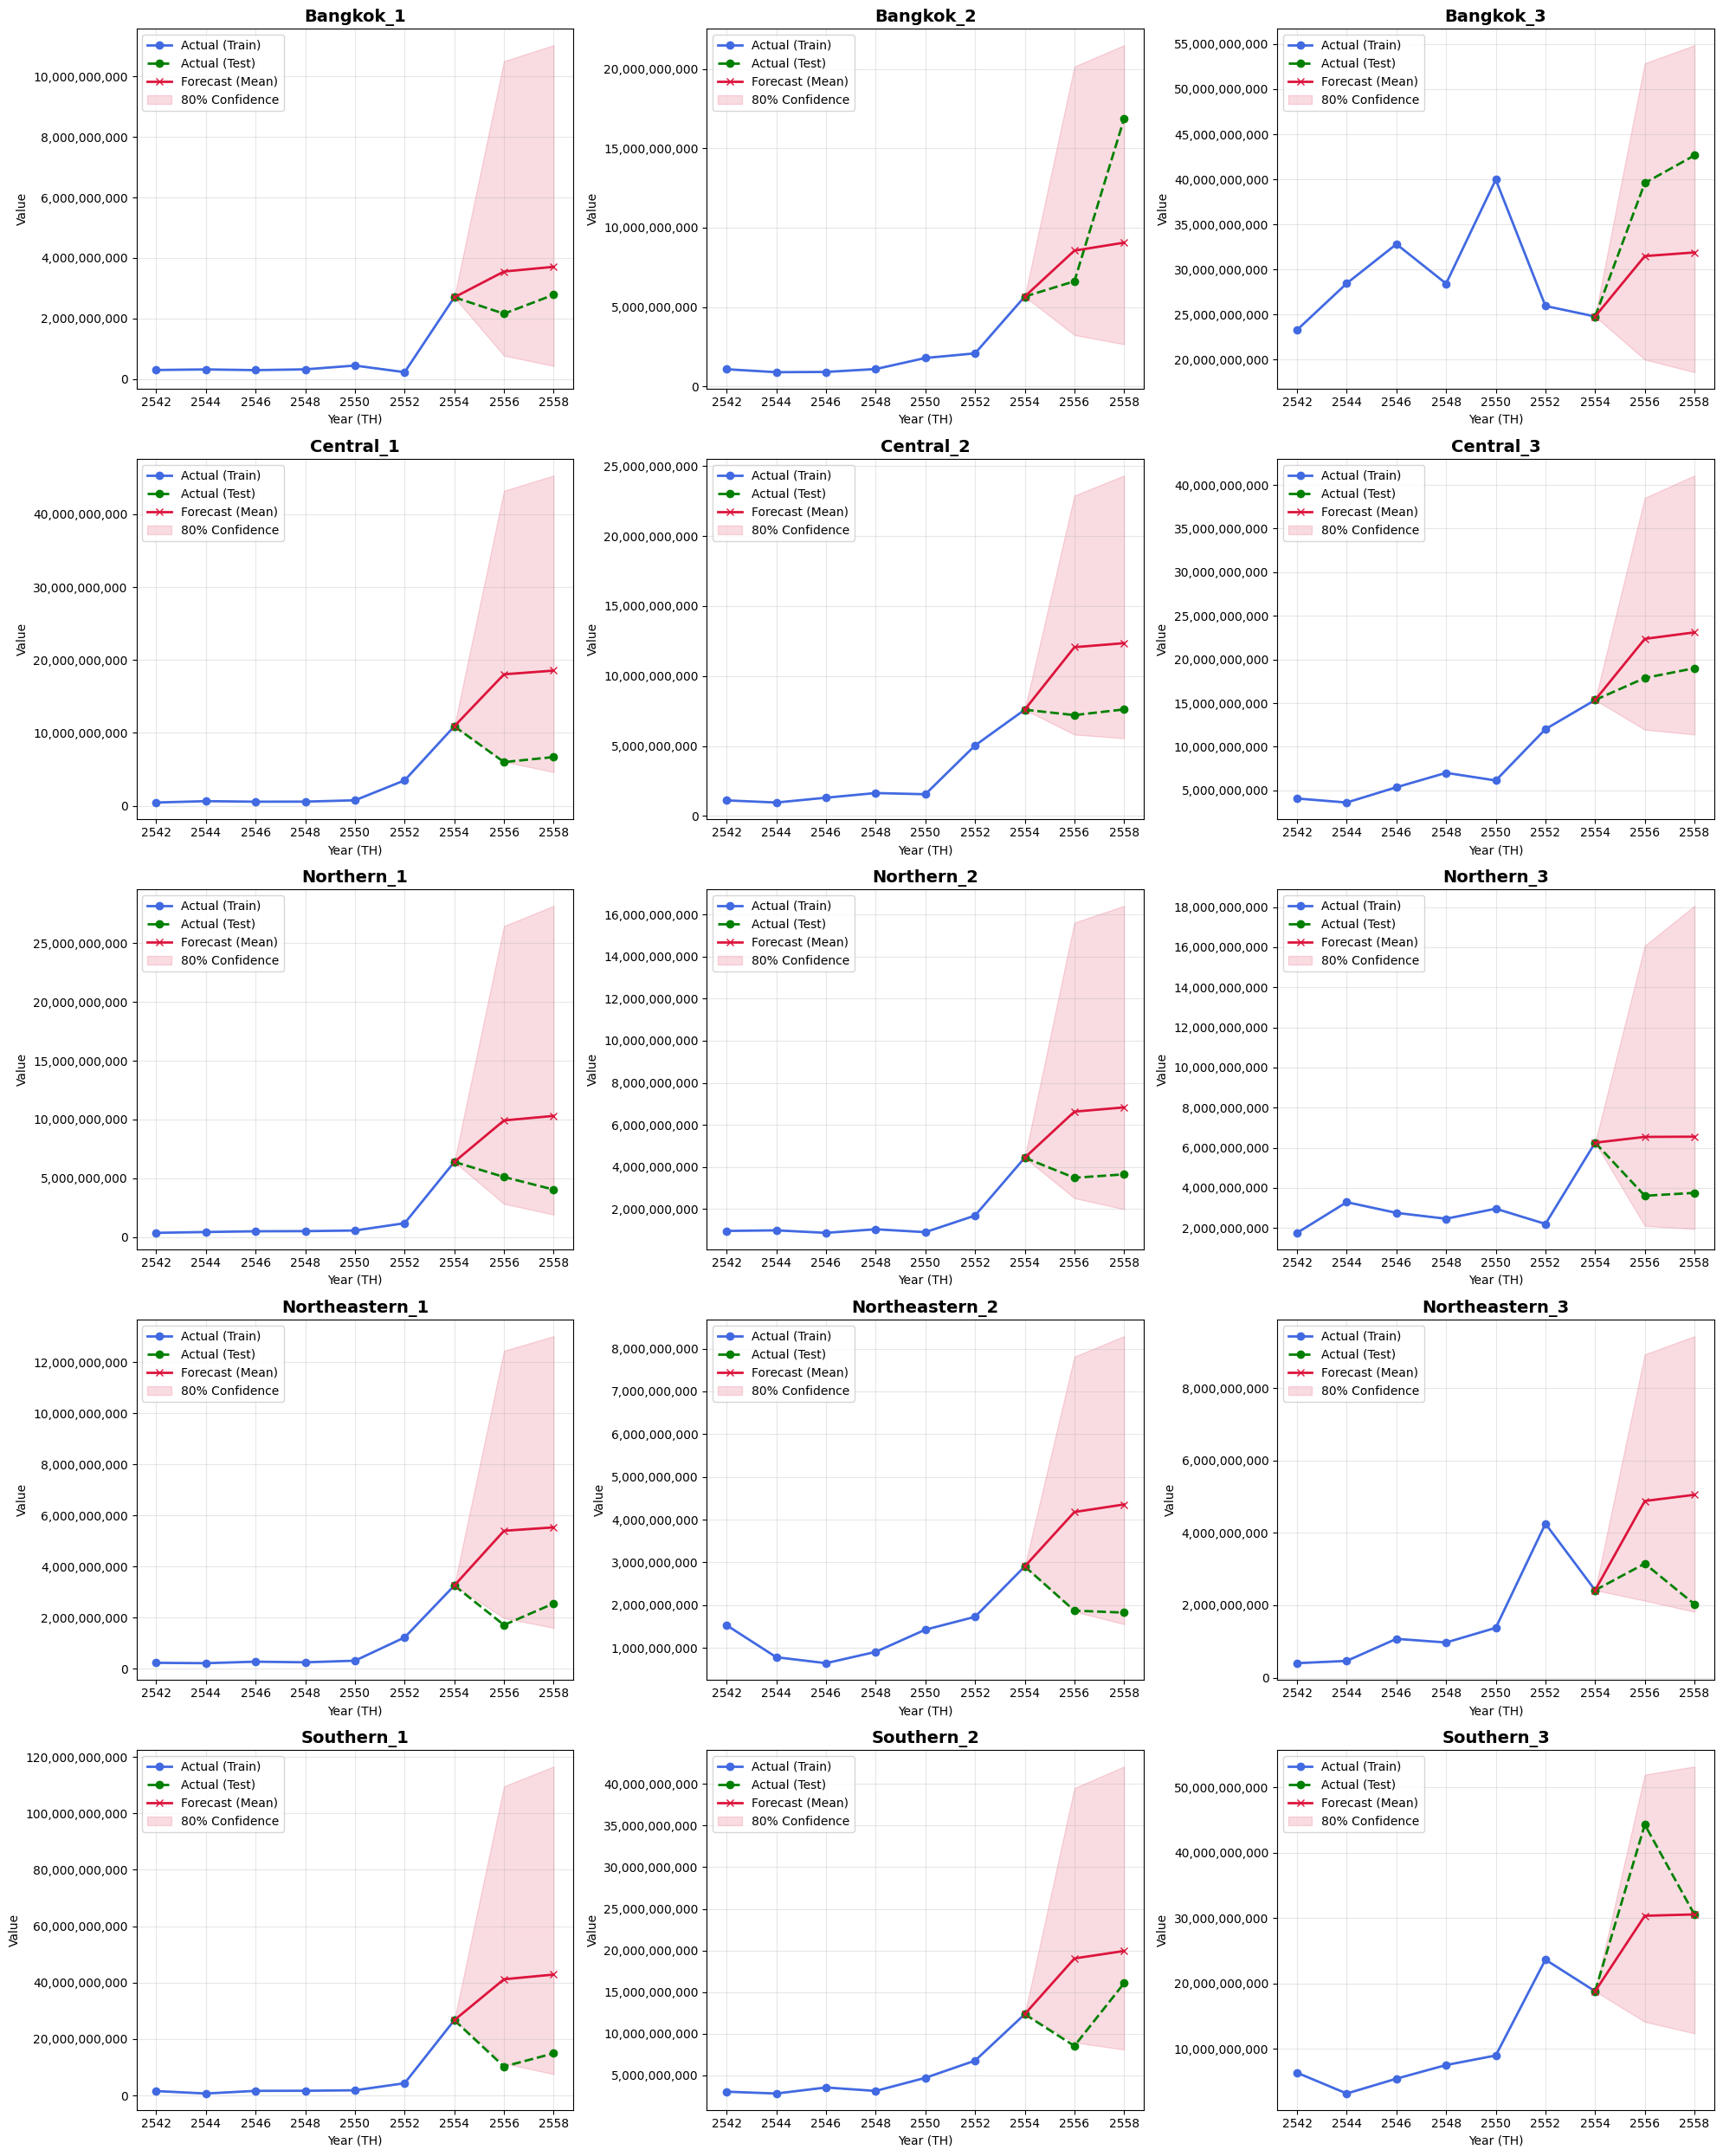

In [10]:
import matplotlib.pyplot as plt

# ดึงชื่อ item_id ทั้งหมด (15 กลุ่ม)
items = comparison["item_id"].unique()

# ตั้งค่าขนาดกราฟรวม (กว้าง 20, สูง 25 นิ้ว) เพื่อให้กราฟ 15 รูปดูไม่อึดอัด
plt.figure(figsize=(20, 25))

# วนลูปวาดกราฟทีละภูมิภาค
for i, item in enumerate(items, 1):
    plt.subplot(5, 3, i)  # สร้าง Grid 5 แถว 3 คอลัมน์

    # 1. ดึงข้อมูลอดีตของ item นี้จาก ts_df
    past = ts_df.loc[item].reset_index()
    past["year_th"] = past["timestamp"].dt.year + 543

    # 2. ดึงข้อมูลพยากรณ์ของ item นี้จากตาราง comparison
    pred = comparison[comparison["item_id"] == item]

    # แบ่งช่วงเวลาของของจริง (Actual)
    past_train = past[past["year_th"] <= 2554]  # อดีตที่โมเดลใช้เรียนรู้
    past_test = past[
        past["year_th"] >= 2554
    ]  # อนาคตที่เอาไว้ทดสอบ (เริ่มจาก 2554 เพื่อให้เส้นเชื่อมกัน)

    # พล็อตเส้นข้อมูลจริง (Actual)
    plt.plot(
        past_train["year_th"],
        past_train["value"],
        marker="o",
        label="Actual (Train)",
        color="royalblue",
        linewidth=2,
    )
    plt.plot(
        past_test["year_th"],
        past_test["value"],
        marker="o",
        linestyle="--",
        label="Actual (Test)",
        color="green",
        linewidth=2,
    )

    # 3. พล็อตเส้นพยากรณ์ (Forecast)
    # ดึงจุดสุดท้ายของปี 2554 มาเป็นจุดเชื่อมกราฟพยากรณ์
    last_train_year = past_train["year_th"].iloc[-1]
    last_train_val = past_train["value"].iloc[-1]

    pred_years = [last_train_year] + pred["year_th"].tolist()
    pred_means = [last_train_val] + pred["mean"].tolist()
    pred_lower = [last_train_val] + pred["0.1"].tolist()
    pred_upper = [last_train_val] + pred["0.9"].tolist()

    # วาดเส้นค่าเฉลี่ยที่ทายได้ และระบายสีช่วงความมั่นใจ 0.1 - 0.9 (80% Confidence Interval)
    plt.plot(
        pred_years,
        pred_means,
        marker="x",
        linestyle="-",
        label="Forecast (Mean)",
        color="crimson",
        linewidth=2,
    )
    plt.fill_between(
        pred_years,
        pred_lower,
        pred_upper,
        color="crimson",
        alpha=0.15,
        label="80% Confidence",
    )

    # ตกแต่งกราฟให้สวยงาม
    plt.title(f"{item}", fontsize=14, fontweight="bold")
    plt.xlabel("Year (TH)")
    plt.ylabel("Value")

    # ใส่ลูกน้ำที่แกน Y ให้ตัวเลขอ่านง่าย
    plt.gca().yaxis.set_major_formatter(
        plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
    )
    plt.grid(True, alpha=0.3)

    # โชว์ป้ายกำกับ (Legend) แค่รูปแรกก็พอจะได้ไม่รก
    plt.legend()

plt.tight_layout()
plt.show()

Loading predictor from path d:\Mini Project\Term Project\AutogluonModels\TimeSeriesPredictor_Backtest
Model not specified in predict, will default to the model with the best validation score: Chronos2SmallFineTuned


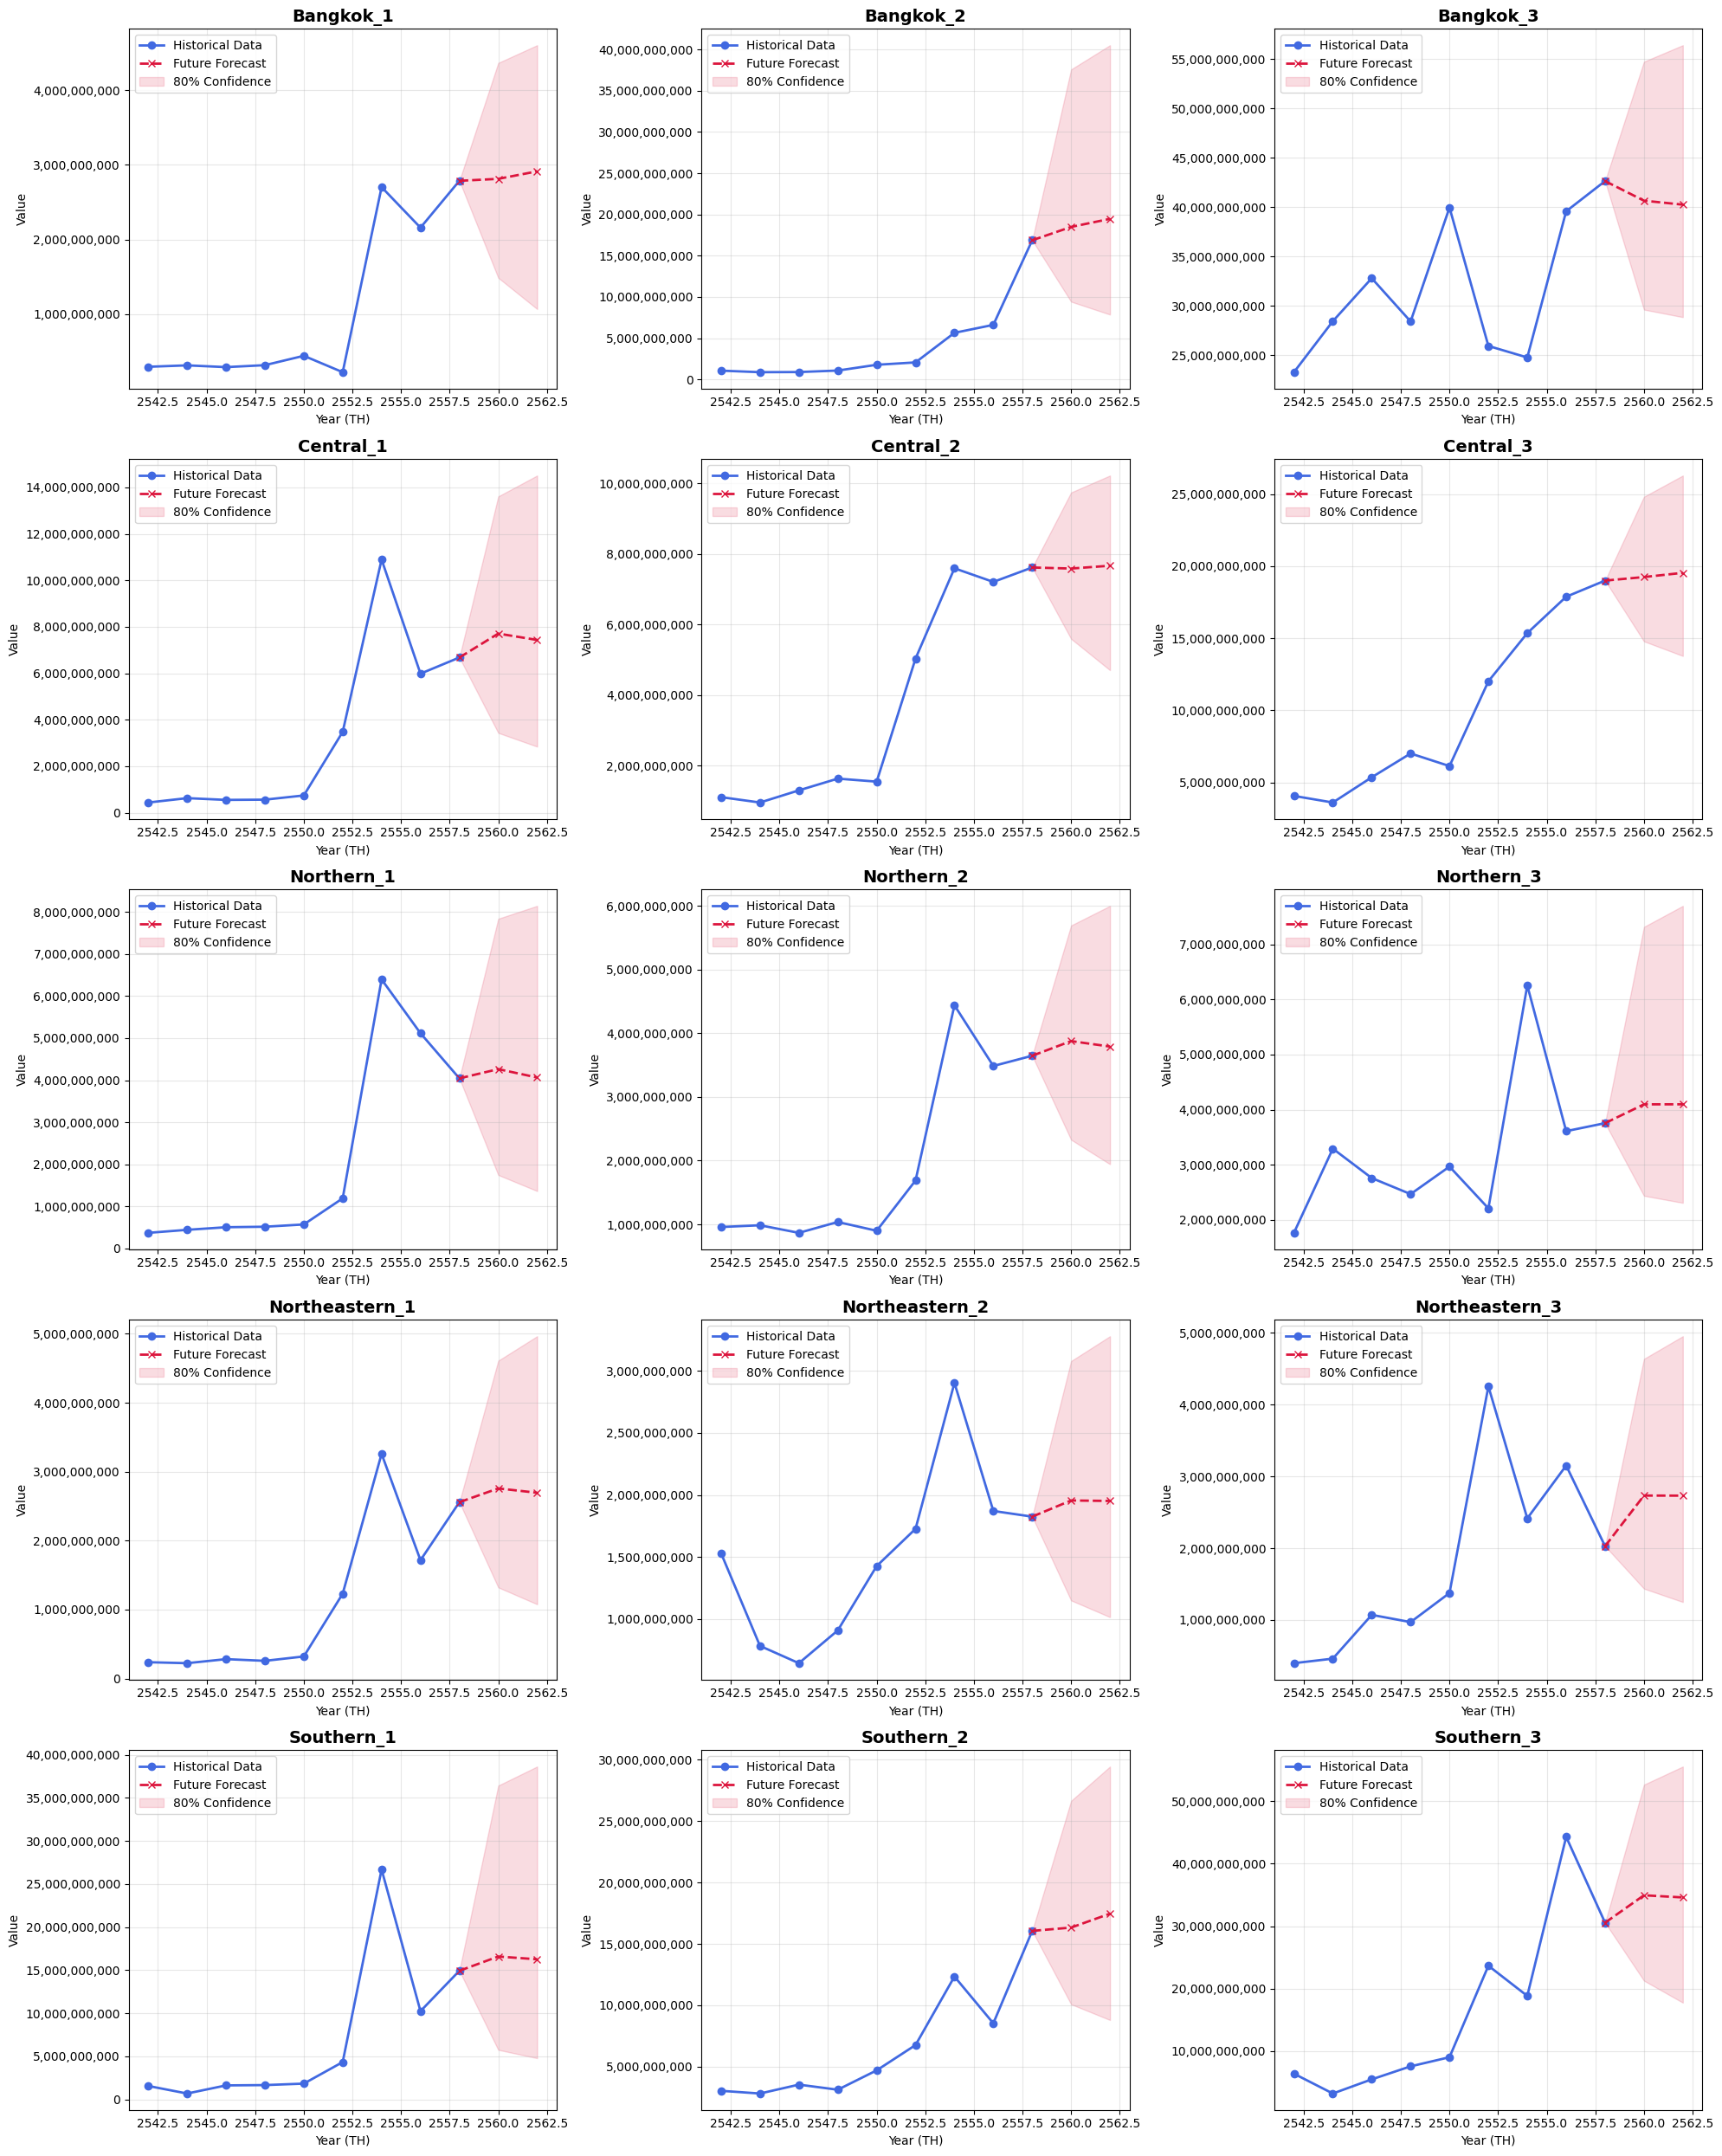

In [11]:
# 1. โหลดโมเดล "ตัวเต็ม" ที่เทรนด้วยข้อมูลทั้งหมดถึงปี 2558 กลับมา
predictor_full = TimeSeriesPredictor.load(
    "../AutogluonModels/TimeSeriesPredictor_Backtest/"
)

# 2. จำลองยอดนักท่องเที่ยว (Covariates) สำหรับปี 2017 และ 2019 (ที่คุณเคยเขียนไว้)
future_data = []
for item_id in ts_df.item_ids:
    last_date = ts_df.loc[item_id].index.max()
    future_dates = pd.date_range(start=last_date, periods=3, freq="2YS-JAN")[1:]
    region = item_id.split("_")[0]

    for date in future_dates:
        base = 35.0  # สมมติยอดนักท่องเที่ยวรวม 35 ล้านคน
        share = {
            "Bangkok": 0.35,
            "Southern": 0.25,
            "Central": 0.15,
            "Northern": 0.15,
            "Northeastern": 0.10,
        }
        tourists_million = (base * share.get(region, 0.1)) + np.random.uniform(
            -0.5, 0.5
        )
        future_tourists = int(max(0.1, tourists_million) * 1000000)

        future_data.append(
            {"item_id": item_id, "timestamp": date, "tourists_mn": future_tourists}
        )

future_covariates = TimeSeriesDataFrame.from_data_frame(
    pd.DataFrame(future_data), id_column="item_id", timestamp_column="timestamp"
)

# 3. สั่งพยากรณ์อนาคต (ปี 2560 และ 2562)
future_predictions = predictor_full.predict(ts_df, known_covariates=future_covariates)
future_predictions = future_predictions.reset_index()
future_predictions["year_th"] = future_predictions["timestamp"].dt.year + 543

# ---------------------------------------------------------
# 4. พล็อตกราฟดูหน้าตาอนาคตที่เราทำนายได้!
# ---------------------------------------------------------
items = ts_df.item_ids
plt.figure(figsize=(20, 25))

for i, item in enumerate(items, 1):
    plt.subplot(5, 3, i)

    # ข้อมูลอดีต
    past = ts_df.loc[item].reset_index()
    past["year_th"] = past["timestamp"].dt.year + 543

    # ข้อมูลพยากรณ์อนาคต
    pred = future_predictions[future_predictions["item_id"] == item]

    # พล็อตอดีต (เส้นสีน้ำเงิน)
    plt.plot(
        past["year_th"],
        past["value"],
        marker="o",
        label="Historical Data",
        color="royalblue",
        linewidth=2,
    )

    # จุดเชื่อมต่อระหว่างอดีตกับอนาคต
    last_year = past["year_th"].iloc[-1]
    last_val = past["value"].iloc[-1]

    pred_years = [last_year] + pred["year_th"].tolist()
    pred_means = [last_val] + pred["mean"].tolist()
    pred_lower = [last_val] + pred["0.1"].tolist()
    pred_upper = [last_val] + pred["0.9"].tolist()

    # พล็อตอนาคต (เส้นสีแดง + แถบความมั่นใจ)
    plt.plot(
        pred_years,
        pred_means,
        marker="x",
        linestyle="--",
        label="Future Forecast",
        color="crimson",
        linewidth=2,
    )
    plt.fill_between(
        pred_years,
        pred_lower,
        pred_upper,
        color="crimson",
        alpha=0.15,
        label="80% Confidence",
    )

    plt.title(f"{item}", fontsize=14, fontweight="bold")
    plt.xlabel("Year (TH)")
    plt.ylabel("Value")
    plt.gca().yaxis.set_major_formatter(
        plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
    )
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()